<a href="https://colab.research.google.com/github/nguyenvuonghongvy/TH_DeepLearning/blob/main/Buoi2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# THỰC HÀNH 3 : ARTIFICIAL NEURAL NETWORK

## 3.1. Nạp thư viện

In [6]:
!pip install scikeras

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier # Corrected import and typo
from keras.layers import Dropout
from sklearn.metrics import f1_score, roc_auc_score, log_loss # Corrected typo
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler


## 3.2. Đọc tập dữ liệu FASHION MNIST

In [7]:
#tải bộ mist fashion dataset
fashion = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


## 3.3. Xử lý dữ liệu

In [8]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

minmax = MinMaxScaler()
x_train = minmax.fit_transform(x_train)
x_test = minmax.transform(x_test)

print("Number of classes:", len(np.unique(y_train)))
print('Classes:', np.unique(y_train))


Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


## 3.4. Trực quan hóa dữ liệu

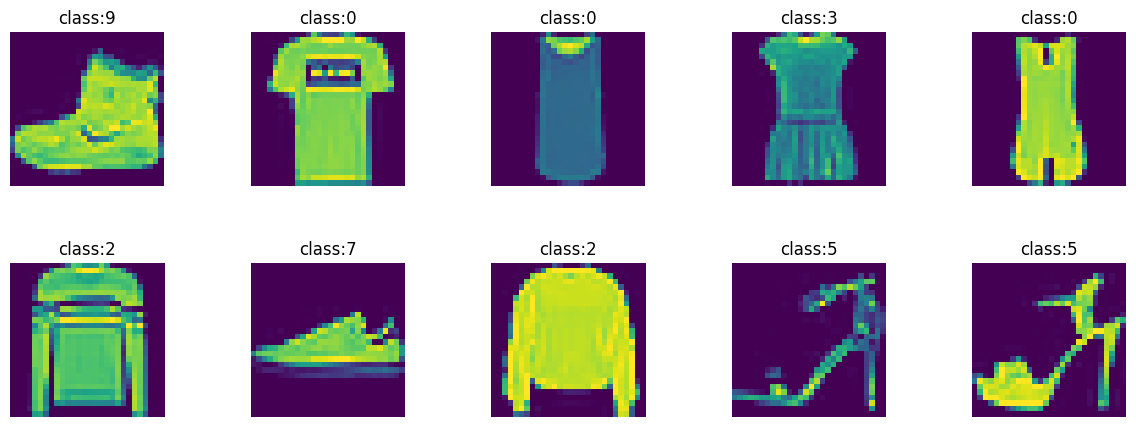

In [9]:
fig, axes = plt.subplots(nrows = 2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(x_train[i].reshape(28, 28))
  ax[i].title.set_text('class:'+str(y_train[i]))
  ax[i].axis('off')
plt.subplots_adjust(hspace=0.5)
plt.show()

## 3.5. Xây dựng mô hình học ANN

In [22]:
fashion_model = Sequential()

fashion_model.add(Dense(input_dim=x_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

fashion_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

## 3.6. Huấn luyện ANN model

In [23]:
model_fit = fashion_model.fit(x_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8235 - loss: 0.5028 - val_accuracy: 0.8503 - val_loss: 0.4075
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8671 - loss: 0.3704 - val_accuracy: 0.8580 - val_loss: 0.3827
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8785 - loss: 0.3312 - val_accuracy: 0.8685 - val_loss: 0.3580
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8879 - loss: 0.3053 - val_accuracy: 0.8707 - val_loss: 0.3476
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8935 - loss: 0.2876 - val_accuracy: 0.8835 - val_loss: 0.3178
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8982 - loss: 0.2741 - val_accuracy: 0.8798 - val_loss: 0.3281
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9027 - loss: 0.2592 - val_accuracy: 0.8878 - val_loss: 0.3188
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9067 - loss: 0.2485 

## 3.7. Đánh giá ANN model

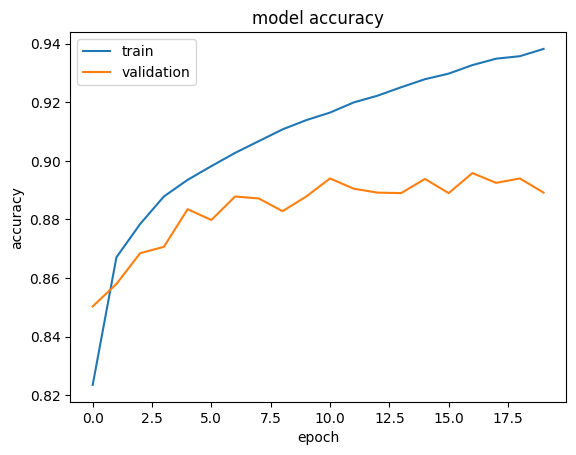

In [24]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

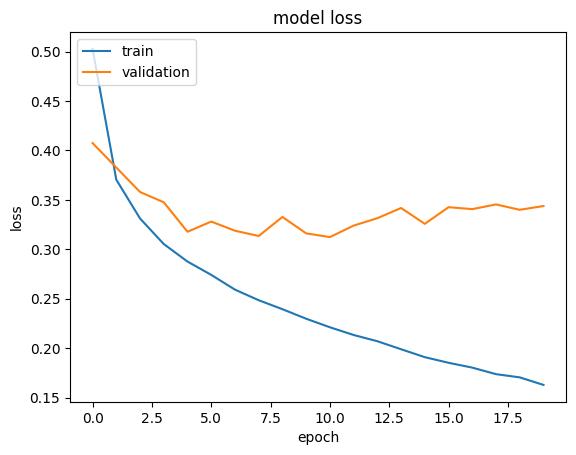

In [25]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

## 3.8. Dự báo ảnh mới

In [26]:
print(np.argmax(fashion_model.predict(x_test)[0]), y_test[0] )
print(np.argmax(fashion_model.predict(x_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


## 3.9. Đọc tập dữ liệu từ file

In [28]:
mnist_train_path = '/content/sample_data/mnist_train_small.csv'
mnist_test_path = '/content/sample_data/mnist_test.csv'
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)

print(mnist_train.head())
print(mnist_train.shape)

   6  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.581  0.582  0.583  \
0  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  7  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.584  0.585  0.586  0.587  0.588  0.589  0.590  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]
(19999, 785)


In [29]:
X_train = mnist_train.iloc[:, 1:]
X_test = mnist_test.iloc[:, 1:]
print(X_train.shape)

y_train = mnist_train.iloc[:, 0]
y_test = mnist_test.iloc[:, 0]

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

(19999, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [37]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(units=256, kernel_initializer='uniform', activation='relu'),
    Dense(units=10, kernel_initializer='uniform', activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model_fit = model.fit(X_train, y_train, epochs=30, verbose=1)
print(np.argmax(model.predict(X_test)[0]), y_test[0])

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8754 - loss: 1.0657
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9357 - loss: 0.2347
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9439 - loss: 0.2078
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9472 - loss: 0.2059
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9525 - loss: 0.1996
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9528 - loss: 0.2165
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9552 - loss: 0.2090
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9594 - loss: 0.1939
Epoch 9/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9657 - loss: 0.1571
Epoch 10/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9675 - loss: 0.1628
Epoch 11/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9680 - loss: 0.1608
Epoch 12/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

In [40]:
img_size = (28, 28)
img = tf.keras.preprocessing.image.load_img('/usr/dress.jpg', color_mode='grayscale', target_size=img_size)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array, (784))
img_array = tf.expand_dims(img, 0) # Trích xuất thêm trục để đưa vào mô hình
img_array = tf.convert_to_tensor(img_array)

print(img_array.shape)
#print(img_array.reshape(None, 784))

img_predict = model.predict(img_array)
print(img_predict)

score = np.argmax(img_predict)
print(score)

(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
[[0.0000000e+00 0.0000000e+00 9.0333447e-02 2.3996039e-25 3.5940114e-32
  1.1904392e-33 4.0350073e-37 9.0966654e-01 4.7087324e-16 0.0000000e+00]]
7
